# One analytics question, three dataframe engines

**Question:** Why can Pandas, Polars, and PySpark express the same analysis yet behave very differently?

Our business question is: **Which movies are both highly rated and widely rated?** We will build that analysis from familiar dataframe operations, run it through three engines, verify that the answers match, and compare how each engine performs the work.

By the end, you should be able to explain performance using three ideas: **where the work runs, when it runs, and how the engine organizes it.**

## Today’s 45-minute route

**Question:** What evidence will we collect before choosing a dataframe engine?

| Time | Teaching question |
|---:|---|
| 0–4 | Are the environment and input data ready? |
| 4–9 | Is the dataset clean, and when would normalization help? |
| 9–15 | What do filtering and grouping do to rows? |
| 15–21 | How does Pandas execute the complete analysis? |
| 21–26 | What changes when Polars uses a parallel native engine? |
| 26–34 | How does PySpark turn the request into partitioned work? |
| 34–40 | Do the answers match, and how does runtime change with scale? |
| 40–45 | Which engine fits which workload? |

The optional Polars planning section is after the 45-minute close. Throughout the demo, keep asking: **where, when, and how?**

## Before the analysis: confirm a fair starting point

**Question:** Are all three engines using the same data, threshold, and machine?

The setup selects the deterministic 1M-row classroom dataset, sets “widely rated” to 1,000 ratings, locates Java for PySpark, and reports package versions. These checks prevent environment differences from masquerading as framework differences.

`FAST_DEMO = True` keeps the live path predictable. The prepared chart later supplies larger measurements without making the class wait.

In [1]:
from pathlib import Path
import os, shutil, time, warnings

import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Keep unexpected warnings visible during class; suppress only known seaborn deprecations.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("colorblind", 3)
FRAMEWORK_COLORS = dict(zip(["Pandas", "Polars", "PySpark"], palette))

FAST_DEMO = True
MIN_RATINGS = 1_000
TOP_N = 10

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RATINGS_PATH = (
    ROOT
    / "data/parquet"
    / ("ratings_1m.parquet" if FAST_DEMO else "ratings_32m.parquet")
)
MOVIES_PATH = ROOT / "data/parquet/movies.parquet"
missing = [path for path in (RATINGS_PATH, MOVIES_PATH) if not path.exists()]
assert not missing, f"Missing {', '.join(map(str, missing))}; run `make data`."

# Make a Homebrew OpenJDK 17 installation visible to local PySpark.
for java_home in [
    Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
    Path("/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
]:
    if "JAVA_HOME" not in os.environ and java_home.exists():
        os.environ["JAVA_HOME"] = str(java_home)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")
java_status = (
    "ready"
    if os.environ.get("JAVA_HOME") or shutil.which("java")
    else "not found (Spark will be skipped)"
)
print(f"Data: {RATINGS_PATH.name} | threshold: {MIN_RATINGS:,}")
print(f"Pandas {pd.__version__} | Polars {pl.__version__} | Java {java_status}")

Data: ratings_1m.parquet | threshold: 1,000
Pandas 3.0.5 | Polars 1.44.1 | Java ready


## 1. Read the data as a table

**Question:** What does one row represent, and which columns will our analysis need?

Each MovieLens row records **one person’s rating of one movie**:

| userId | movieId | rating | timestamp |
|---:|---:|---:|---:|
| 1 | 296 | 5.0 | … |
| 1 | 306 | 3.5 | … |

`movieId` connects ratings to titles, and `rating` supplies the score. `userId` and `timestamp` are useful context but are not required by our final query. The next cell confirms the dataset size and shows real rows before we transform anything.

In [2]:
ratings = pd.read_parquet(RATINGS_PATH)
movies = pd.read_parquet(MOVIES_PATH)

print(
    f"{len(ratings):,} ratings • {ratings['userId'].nunique():,} users • {movies['movieId'].nunique():,} movies"
)
display(ratings[["userId", "movieId", "rating"]].head(5).style.hide(axis="index"))

1,000,000 ratings • 167,203 users • 87,585 movies


userId,movieId,rating
163692,201749,4.000000
63885,914,3.000000
197767,593,3.500000
140531,1291,4.000000
159429,265148,2.500000


### Check data quality before analysis

**Question:** Are missing values or duplicate rows capable of changing our movie rankings?

Before transforming data, inspect it. A missing `movieId` would prevent a rating from joining to a title, a missing `rating` would affect averages, and an exact duplicate would count the same event twice.

The next cell reports missing values by column and counts **exact duplicate rows**. We do not automatically remove repeated user or movie IDs because those repetitions are expected: many users rate many movies.

In [3]:
quality_report = pd.DataFrame(
    {
        "data_type": ratings.dtypes.astype(str),
        "missing_values": ratings.isna().sum(),
        "distinct_values": ratings.nunique(),
    }
)
exact_duplicate_rows = int(ratings.duplicated().sum())

print(f"Exact duplicate rows: {exact_duplicate_rows:,}")
display(
    quality_report.style.format({"missing_values": "{:,}", "distinct_values": "{:,}"})
)

assert (
    quality_report["missing_values"].sum() == 0
), "Resolve missing values before benchmarking."
assert exact_duplicate_rows == 0, "Resolve exact duplicate rows before benchmarking."

Exact duplicate rows: 0


,data_type,missing_values,distinct_values
userId,int32,0,"167,203"
movieId,int32,0,"27,802"
rating,float32,0,10
timestamp,int64,0,"971,981"


### Normalize a feature without changing its meaning

**Question:** How can we place ratings on a 0–1 scale, and should the ranking query use that normalized value?

MovieLens ratings range from 0.5 to 5.0. Min–max normalization maps that interval to 0–1:

```text
normalized rating = (rating − 0.5) / (5.0 − 0.5)
```

Normalization is useful when ratings must be combined with features measured on different scales, especially in machine-learning workflows. Our final ranking keeps the original stars because they are easier to interpret. This linear transformation would preserve their ordering, so it would not change which average rating is higher.

In [4]:
RATING_MIN, RATING_MAX = 0.5, 5.0
ratings_normalized = ratings.assign(
    rating_normalized=(ratings["rating"] - RATING_MIN) / (RATING_MAX - RATING_MIN)
)

assert ratings_normalized["rating_normalized"].between(0, 1).all()
display(
    ratings_normalized[["movieId", "rating", "rating_normalized"]]
    .head(8)
    .style.format({"rating": "{:.1f}", "rating_normalized": "{:.3f}"})
    .hide(axis="index")
)

movieId,rating,rating_normalized
201749,4.0,0.778
914,3.0,0.556
593,3.5,0.667
1291,4.0,0.778
265148,2.5,0.444
3005,3.0,0.556
319,0.5,0.000
1214,5.0,1.000


## Build the first operation: filter rows

**Question:** Which individual ratings are at least 4.5 stars?

A filter evaluates a condition for every row and keeps only rows where it is true. We start in Pandas so the operation is familiar; later, the same idea appears inside every engine’s complete query.

Before running the cell, predict whether most of the one million ratings will survive `rating >= 4.5`.

In [5]:
high_ratings = ratings.loc[
    ratings["rating"] >= 4.5,
    ["userId", "movieId", "rating"],
]
print(f"Pandas returned {len(high_ratings):,} matching rows immediately.")
display(high_ratings.head(5).style.hide(axis="index"))

Pandas returned 236,115 matching rows immediately.


userId,movieId,rating
121305,1214,5.000000
187312,1186,4.500000
14147,953,4.500000
80722,47,4.500000
109258,1213,4.500000


### Does similar syntax imply similar execution?

**Question:** If three APIs express the same filter, do they necessarily perform the work in the same way?

```python
# Pandas
ratings.loc[ratings["rating"] >= 4.5, ["userId", "movieId", "rating"]]

# Polars
ratings.filter(pl.col("rating") >= 4.5).select("userId", "movieId", "rating")

# PySpark
ratings.filter(F.col("rating") >= 4.5).select("userId", "movieId", "rating")
```

The **intent** is identical, but syntax does not reveal whether execution is immediate, parallel, or distributed. To expose those differences, we need grouping.

## Build the second operation: group and aggregate

**Question:** For each movie, what are its average rating and number of ratings?

Grouping collects rows with the same `movieId`; aggregation reduces each group to summary values:

```text
ratings → group by movieId → average(rating) + count(rows)
```

Predict the output shape: one million input rows cannot produce more groups than distinct movie IDs. The following result answers that prediction with one row per rated movie.

In [6]:
movie_stats = (
    ratings.groupby("movieId")["rating"]
    .agg(average_rating="mean", rating_count="count")
    .reset_index()
)
print(f"One million input rows became {len(movie_stats):,} movie groups.")
display(
    movie_stats.head(8)
    .style.format({"average_rating": "{:.2f}", "rating_count": "{:,}"})
    .hide(axis="index")
)

One million input rows became 27,802 movie groups.


movieId,average_rating,rating_count
1,3.90,"2,171"
2,3.25,891
3,3.12,423
4,2.76,99
5,3.02,396
6,3.86,932
7,3.40,425
8,3.17,49


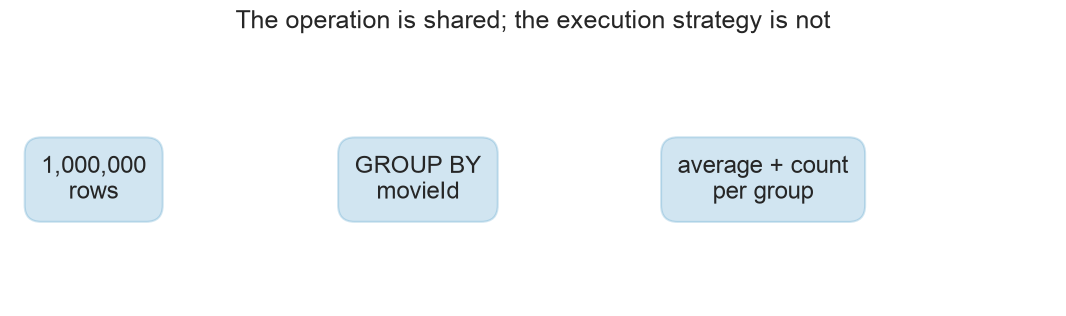

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis("off")
steps = [
    (0.08, "1,000,000\nrows"),
    (0.39, "GROUP BY\nmovieId"),
    (0.72, "average + count\nper group"),
]
for x, label in steps:
    ax.text(
        x,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=17,
        bbox=dict(
            boxstyle="round,pad=.7",
            facecolor=palette[0],
            alpha=0.18,
            edgecolor=palette[0],
        ),
    )
for start, end in [(0.18, 0.29), (0.51, 0.62)]:
    ax.annotate(
        "", xy=(end, 0.5), xytext=(start, 0.5), arrowprops=dict(arrowstyle="->", lw=2)
    )
ax.set_title("The operation is shared; the execution strategy is not", pad=18)
plt.tight_layout()
plt.show()

### Can every engine describe the same aggregation?

**Question:** How do Pandas, Polars, and PySpark each say “one row per movie, with an average and count”?

```python
# Pandas
ratings.groupby("movieId").agg(average_rating=("rating", "mean"), rating_count=("rating", "count"))

# Polars
ratings.group_by("movieId").agg(pl.col("rating").mean(), pl.len())

# PySpark
ratings.groupBy("movieId").agg(F.avg("rating"), F.count("*"))
```

The punctuation changes, but the data operation does not. We now have the ingredients needed to make “highly rated and widely rated” precise.

## The shared analytical challenge

**Question:** Which movies are highly rated and supported by enough ratings to be credible?

We define **widely rated** as at least 1,000 ratings. The complete query is:

```text
ratings → group by movieId → average + count → keep count ≥ 1,000
        → join titles → sort by average, count, and movieId
```

The threshold prevents one five-star rating from outranking a movie supported by thousands of viewers. We execute this exact pipeline in all three engines.

## 2. Establish a Pandas reference result

**Question:** Where and when does Pandas execute the complete analysis?

Pandas runs these dataframe operations on one machine and returns a materialized result directly. Its operations are vectorized rather than Python loops over rows, but the working data must still fit comfortably in local memory.

```text
Python API → local dataframe operations → materialized result
```

The next cell computes the full pipeline and becomes our correctness reference.

In [8]:
# Live timings use one cold, end-to-end run: read files, execute, and materialize the result.
pandas_start = time.perf_counter()
pandas_ratings = pd.read_parquet(RATINGS_PATH, columns=["movieId", "rating"])
pandas_movies = pd.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
pandas_result = (
    pandas_ratings.groupby("movieId")
    .agg(average_rating=("rating", "mean"), rating_count=("rating", "count"))
    .query("rating_count >= @MIN_RATINGS")
    .reset_index()
    .merge(pandas_movies, on="movieId")
    .sort_values(
        ["average_rating", "rating_count", "movieId"], ascending=[False, False, True]
    )
    .reset_index(drop=True)
)
pandas_runtime = time.perf_counter() - pandas_start
LIVE_ROWS = len(pandas_ratings)

display(
    pandas_result.head(TOP_N)[["title", "average_rating", "rating_count"]]
    .style.format({"average_rating": "{:.2f}", "rating_count": "{:,}"})
    .hide(axis="index")
)

title,average_rating,rating_count
"Shawshank Redemption, The (1994)",4.38,"3,212"
"Godfather, The (1972)",4.31,"2,000"
"Godfather: Part II, The (1974)",4.27,"1,332"
Schindler's List (1993),4.27,"2,337"
"Usual Suspects, The (1995)",4.24,"2,068"
Spirited Away (Sen to Chihiro no kamikakushi) (2001),4.23,"1,041"
One Flew Over the Cuckoo's Nest (1975),4.22,"1,371"
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.21,"1,008"
Fight Club (1999),4.20,"2,393"
Pulp Fiction (1994),4.20,"2,989"


### Check whether the reference answer makes sense

**Question:** Which familiar movies survive both the quality and popularity requirements?

The table gives the exact sorted result; the bar chart makes the top values easier to discuss. Look for ratings near five stars and counts above the 1,000-rating threshold.

This is the reference answer that Polars and PySpark must reproduce.

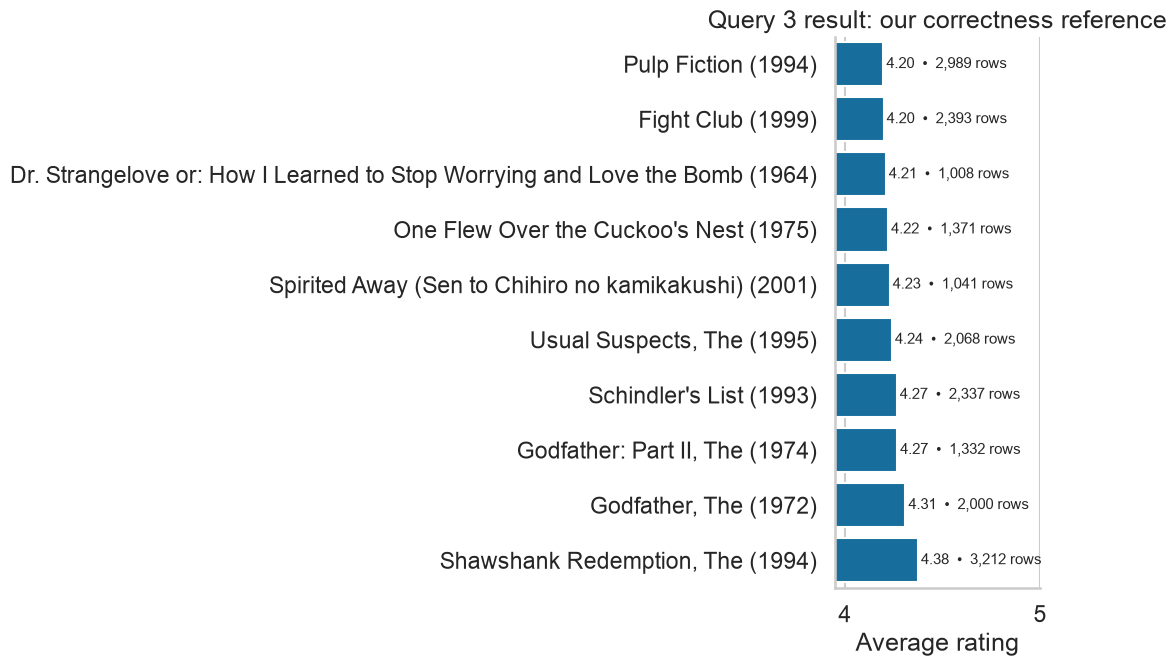

In [9]:
top_movies = pandas_result.head(TOP_N).sort_values("average_rating")
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=top_movies,
    x="average_rating",
    y="title",
    color=FRAMEWORK_COLORS["Pandas"],
    ax=ax,
)
ax.set(
    title="Query 3 result: our correctness reference",
    xlabel="Average rating",
    ylabel="",
)
ax.set_xlim(max(0, top_movies.average_rating.min() - 0.25), 5)
for bar, (_, row) in zip(ax.patches, top_movies.iterrows()):
    ax.text(
        row.average_rating + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{row.average_rating:.2f}  •  {row.rating_count:,.0f} rows",
        va="center",
        fontsize=11,
    )
sns.despine()
plt.tight_layout()
plt.show()

## 3. Run the same analysis with Polars

**Question:** Can Polars answer the same question faster while staying on one machine?

The API still describes groups, filters, joins, and sorting. Polars sends expression work to a native, multithreaded engine that can use several CPU cores.

```text
Python API → parallel native engine → materialized result
```

The next cell performs the same end-to-end work as Pandas: read, execute, and materialize the sorted answer.

In [10]:
polars_start = time.perf_counter()
pl_ratings = pl.read_parquet(RATINGS_PATH, columns=["movieId", "rating"])
pl_movies = pl.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
polars_result = (
    pl_ratings.group_by("movieId")
    .agg(
        pl.col("rating").mean().alias("average_rating"), pl.len().alias("rating_count")
    )
    .filter(pl.col("rating_count") >= MIN_RATINGS)
    .join(pl_movies, on="movieId")
    .sort(["average_rating", "rating_count", "movieId"], descending=[True, True, False])
)
polars_runtime = time.perf_counter() - polars_start
polars_result.head(TOP_N)

movieId,average_rating,rating_count,title
i32,f32,u32,str
318,4.375311,3212,"""Shawshank Redemption, The (199…"
858,4.31075,2000,"""Godfather, The (1972)"""
1221,4.268394,1332,"""Godfather: Part II, The (1974)"""
527,4.266581,2337,"""Schindler's List (1993)"""
50,4.242021,2068,"""Usual Suspects, The (1995)"""
5618,4.230067,1041,"""Spirited Away (Sen to Chihiro …"
1193,4.222101,1371,"""One Flew Over the Cuckoo's Nes…"
750,4.210318,1008,"""Dr. Strangelove or: How I Lear…"
2959,4.199122,2393,"""Fight Club (1999)"""


## 4. Turn the analysis into partitioned work with PySpark

**Question:** How does PySpark transform our request into tasks, and will that machinery help on only one million rows?

```text
Python API → logical plan → Catalyst optimizer → physical tasks → executors
```

The **driver** coordinates the query. **Executors** process partitions—portions of the input that can be worked on separately. Here all roles run on one laptop; the same architecture can extend across machines.

Predict the result: will task scheduling outweigh JVM startup and coordination costs?

In [11]:
spark_result = spark_result_pd = None
spark_runtime = spark = None
try:
    from pyspark.sql import SparkSession, functions as F

    spark_start = (
        time.perf_counter()
    )  # Cold, end-to-end: startup, reads, query, and collection.
    spark = (
        SparkSession.builder.master("local[*]")
        .appName("MovieLens TA demo")
        .config("spark.ui.enabled", "false")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")
    sr, sm = spark.read.parquet(str(RATINGS_PATH)), spark.read.parquet(str(MOVIES_PATH))
    spark_result = (
        sr.groupBy("movieId")
        .agg(
            F.avg("rating").alias("average_rating"), F.count("*").alias("rating_count")
        )
        .filter(F.col("rating_count") >= MIN_RATINGS)
        .join(sm.select("movieId", "title"), "movieId")
        .orderBy(F.desc("average_rating"), F.desc("rating_count"), F.asc("movieId"))
    )
    spark_result_pd = spark_result.toPandas()
    spark_runtime = time.perf_counter() - spark_start
    display(spark_result_pd.head(TOP_N))
except Exception as exc:
    spark_result = spark_result_pd = None
    print(f"Spark skipped: {type(exc).__name__}: {exc}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/27 13:26:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,movieId,average_rating,rating_count,title
0,318,4.375311,3212,"Shawshank Redemption, The (1994)"
1,858,4.310750,2000,"Godfather, The (1972)"
2,1221,4.268393,1332,"Godfather: Part II, The (1974)"
3,527,4.266581,2337,Schindler's List (1993)
4,50,4.242021,2068,"Usual Suspects, The (1995)"
5,5618,4.230067,1041,Spirited Away (Sen to Chihiro no kamikakushi) ...
6,1193,4.222101,1371,One Flew Over the Cuckoo's Nest (1975)
7,750,4.210317,1008,Dr. Strangelove or: How I Learned to Stop Worr...
8,2959,4.199122,2393,Fight Club (1999)
9,296,4.197892,2989,Pulp Fiction (1994)


### Interpret Spark’s small-data result

**Question:** Why can an engine designed for distributed jobs lose a race on one laptop?

Spark pays fixed costs before useful row processing begins:

- start the JVM and create a session;
- optimize a logical plan;
- schedule tasks and coordinate partitions;
- collect the final result to the driver.

One million rows fit comfortably here, so fixed costs dominate. The next output reduces the physical plan to the stages worth reading aloud: **scan → aggregate → shuffle → join → sort**.

In [12]:
if spark_result is not None:
    display(Markdown("""
**Plan to read aloud:** Parquet scan → partial aggregate → shuffle → final aggregate → join → sort

Spark also projects the required columns and uses adaptive execution. Run
`spark_result.explain("formatted")` after class to inspect the full physical plan.
"""))


**Plan to read aloud:** Parquet scan → partial aggregate → shuffle → final aggregate → join → sort

Spark also projects the required columns and uses adaptive execution. Run
`spark_result.explain("formatted")` after class to inspect the full physical plan.


## 5. Trust the answers before timing the engines

**Question:** Is a runtime comparison meaningful before we prove that every engine computed the same result?

No. A fast wrong answer is still wrong. The next cell normalizes row order and numeric types, then compares Polars and PySpark with the Pandas reference.

After correctness, we separate two kinds of evidence:

- **Live demo:** one cold, end-to-end run; useful for immediacy, not ranking.
- **Prepared benchmark:** median of three end-to-end runs; useful for scaling.

Both measure **read → group → filter → join → sort → materialize**.

In [13]:
def comparable(frame):
    return (
        frame[["movieId", "average_rating", "rating_count"]]
        .sort_values("movieId")
        .reset_index(drop=True)
    )


pd.testing.assert_frame_equal(
    comparable(pandas_result),
    comparable(polars_result.to_pandas()),
    check_dtype=False,
    atol=1e-6,
    rtol=1e-6,
)
print("✓ Pandas matches Polars")
if spark_result_pd is not None:
    pd.testing.assert_frame_equal(
        comparable(pandas_result),
        comparable(spark_result_pd),
        check_dtype=False,
        atol=1e-6,
        rtol=1e-6,
    )
    print("✓ PySpark matches")

✓ Pandas matches Polars
✓ PySpark matches


Live demo — one cold, end-to-end run (do not treat as a ranking)


framework,rows,runtime_seconds
Pandas,"1,000,000",0.026
Polars,"1,000,000",0.085
PySpark,"1,000,000",4.434


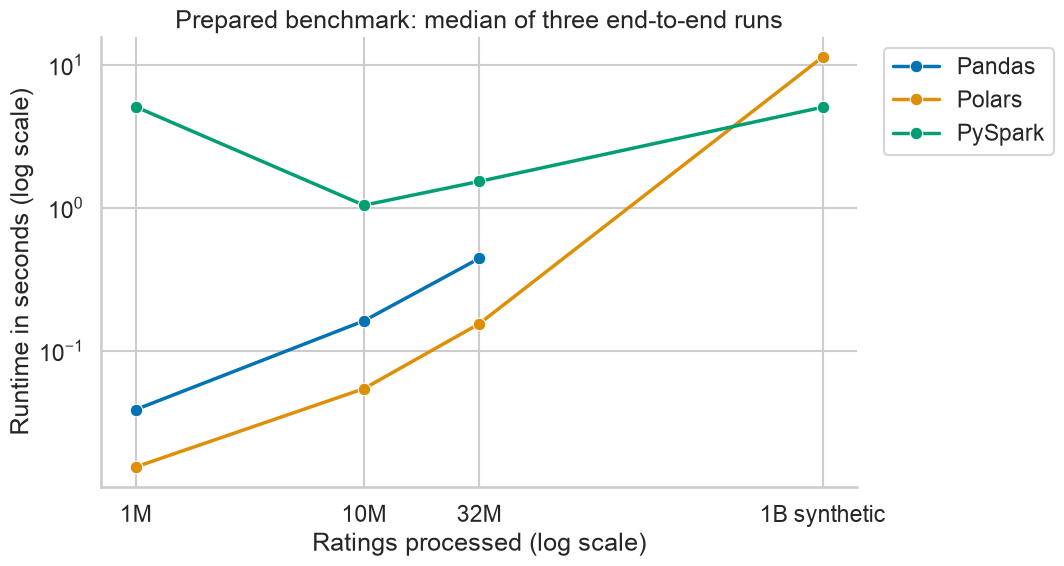

In [14]:
prepared = pd.read_csv(ROOT / "results/benchmark_results_simple.csv")

# Show this session separately; never overwrite repeatable benchmark results with one-shot timings.
live = pd.DataFrame(
    [
        {"framework": framework, "rows": LIVE_ROWS, "runtime_seconds": runtime}
        for framework, runtime in {
            "Pandas": pandas_runtime,
            "Polars": polars_runtime,
            "PySpark": spark_runtime,
        }.items()
        if runtime is not None
    ]
)
print("Live demo — one cold, end-to-end run (do not treat as a ranking)")
display(
    live.style.format({"rows": "{:,}", "runtime_seconds": "{:.3f}"}).hide(axis="index")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=prepared,
    x="rows",
    y="runtime_seconds",
    hue="framework",
    marker="o",
    palette=FRAMEWORK_COLORS,
    linewidth=2.5,
    markersize=9,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(
    title="Prepared benchmark: median of three end-to-end runs",
    xlabel="Ratings processed (log scale)",
    ylabel="Runtime in seconds (log scale)",
)
ax.set_xticks(
    [1_000_000, 10_000_000, 32_000_000, 1_024_006_528],
    labels=["1M", "10M", "32M", "1B synthetic"],
)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

### Read the scaling evidence, not a universal ranking

**Question:** What changes as the input grows from 1M rows to the 1B-row synthetic test?

The **1B synthetic** point repeats the 32M ratings file as 32 Parquet partitions; it tests scale, not new movie behavior.

On this 24 GB laptop, the median of three runs shows:

- Polars is faster from 1M through 32M rows;
- near 1B rows, local PySpark takes **5.05s**, versus **11.32s** for Polars;
- Pandas is omitted at 1B to avoid an unsafe memory experiment.

The answer is not “Spark wins after exactly N rows.” Workload shape, memory, startup, partitioning, and deployment determine the crossover.

## 6. Compare the execution architectures

**Question:** What is the defining execution difference among Pandas, Polars, and PySpark?

- **Pandas:** local dataframe operations with a broad exploration ecosystem.
- **Polars:** a parallel native engine for analytical work on one machine.
- **PySpark:** an optimized task engine whose partitioned plan can span machines.

The following table compares when work runs, intended scale, and the role of the Python API.

In [15]:
framework_summary = pd.DataFrame(
    [
        [
            "Pandas",
            "As operations are requested",
            "One machine",
            "Calls local native operations",
        ],
        [
            "Polars",
            "As operations are requested",
            "One machine, parallel",
            "Runs expressions in a native engine",
        ],
        [
            "PySpark",
            "When a result is requested",
            "One or many machines",
            "Builds plans for Spark",
        ],
    ],
    columns=["Framework", "When work runs", "Designed scale", "Role of Python"],
)

framework_summary.style.hide(axis="index").set_properties(**{"text-align": "left"})

Framework,When work runs,Designed scale,Role of Python
Pandas,As operations are requested,One machine,Calls local native operations
Polars,As operations are requested,"One machine, parallel",Runs expressions in a native engine
PySpark,When a result is requested,One or many machines,Builds plans for Spark


### Follow one instruction through each stack

**Question:** After Python receives a dataframe instruction, what path does it follow before a result appears?

The diagram traces the same request through each stack. Read left to right and identify where expensive computation occurs. This connects the syntax we wrote to the runtimes we measured.

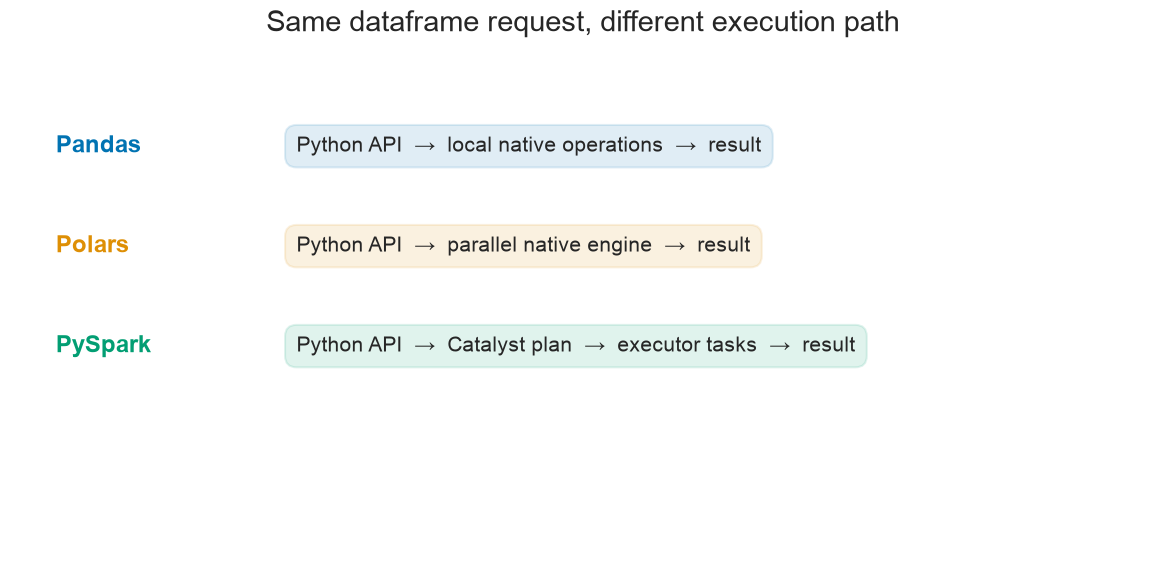

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")
paths = [
    ("Pandas", "Python API  →  local native operations  →  result", "Pandas"),
    ("Polars", "Python API  →  parallel native engine  →  result", "Polars"),
    (
        "PySpark",
        "Python API  →  Catalyst plan  →  executor tasks  →  result",
        "PySpark",
    ),
]
for y, (framework, path, color_key) in zip([0.82, 0.62, 0.42, 0.22], paths):
    color = FRAMEWORK_COLORS[color_key]
    ax.text(0.04, y, framework, fontsize=17, weight="bold", color=color, va="center")
    ax.text(
        0.25,
        y,
        path,
        fontsize=15,
        va="center",
        bbox=dict(
            boxstyle="round,pad=.55", facecolor=color, alpha=0.12, edgecolor=color
        ),
    )
ax.set_title("Same dataframe request, different execution path", fontsize=21, pad=18)
plt.tight_layout()
plt.show()

## 7. Choose an engine from the workload, not the benchmark winner

**Question:** Which engine best fits each realistic workload?

Ask the room to decide before revealing the guide:

1. Interactive exploration of a 5 GB file with an established Python analytics stack.
2. A repeated 100 GB analytical pipeline on one strong machine.
3. A multi-terabyte scheduled job that must scale beyond one machine.

<details>
<summary><strong>Reveal the simplified guide</strong></summary>

| Tool | Execution mental model | Good fit |
|---|---|---|
| **Pandas** | Direct local dataframe operations | Exploration and small/medium local data |
| **Polars** | Parallel local dataframe engine | Analytical pipelines on one machine |
| **PySpark** | Optimized partitioned task engine | Processing that must scale across machines |

Likely answers are **Pandas**, **Polars**, and **PySpark**, respectively.

</details>

Speed is one input. Team skills, ecosystem, deployment, reliability, and workload shape also matter.

In [17]:
# Release the local Spark session after the demo.
if spark is not None:
    spark.stop()

## 8. Close the loop

**Question:** What should you remember when similar dataframe syntax produces different performance?

1. **Start with intent:** all three engines express filters, groups, joins, aggregates, and sorting.
2. **Verify correctness first:** equivalent-looking code must produce equivalent answers before timing matters.
3. **Explain runtime through architecture:** ask where work runs, when it starts, and how the engine organizes it.

```text
same analytical question
          ↓
Pandas: local operations | Polars: parallel native engine | PySpark: partitioned tasks
          ↓
choose using data size, memory, deployment, ecosystem, and team needs
```

The benchmark winner is not automatically the best tool. The best tool is the one whose execution model fits the workload you actually have.

## Appendix: optional Polars planning interface

**Question:** How can Polars optimize a complete query before it loads and processes the data?

This section is **outside the 45-minute core demo**. `scan_parquet` records a source without reading it immediately, expressions build a plan, and `collect()` executes the plan and materializes the answer.

This matters for the prepared 1B-row measurement: Polars can read required columns and avoid constructing one enormous input dataframe before the query begins.

In [18]:
polars_lazy_query = (
    pl.scan_parquet(RATINGS_PATH)
    .select("movieId", "rating")
    .group_by("movieId")
    .agg(
        pl.col("rating").mean().alias("average_rating"),
        pl.len().alias("rating_count"),
    )
    .filter(pl.col("rating_count") >= MIN_RATINGS)
    .join(
        pl.scan_parquet(MOVIES_PATH).select("movieId", "title"),
        on="movieId",
    )
    .sort(
        ["average_rating", "rating_count", "movieId"],
        descending=[True, True, False],
    )
)

plan_lines = polars_lazy_query.explain(optimized=True).splitlines()
print("Optimized plan preview (no query result has been materialized yet):")
print("\n".join(plan_lines[:14]))

polars_lazy_result = polars_lazy_query.collect()
comparison_columns = ["movieId", "average_rating", "rating_count"]
pd.testing.assert_frame_equal(
    pandas_result[comparison_columns].sort_values("movieId").reset_index(drop=True),
    polars_lazy_result.select(comparison_columns)
    .sort("movieId")
    .to_pandas()
    .reset_index(drop=True),
    check_dtype=False,
    atol=1e-6,
    rtol=1e-6,
)
polars_lazy_result.head(TOP_N)

Optimized plan preview (no query result has been materialized yet):
SORT BY [descending: [true, true, false]] [col("average_rating"), col("rating_count"), col("movieId")]
  INNER JOIN:
  LEFT PLAN ON: [col("movieId")]
    FILTER col("rating_count") >= 1000
    FROM
      AGGREGATE[maintain_order: false]
        [col("rating").mean().alias("average_rating"), len().alias("rating_count")] BY [col("movieId")]
        FROM
        Parquet SCAN [/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/data/parquet/ratings_1m.parquet]
        PROJECT 2/4 COLUMNS
        ESTIMATED ROWS: 1000000
  RIGHT PLAN ON: [col("movieId")]
    Parquet SCAN [/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/data/parquet/movies.parquet]
    PROJECT 2/3 COLUMNS


movieId,average_rating,rating_count,title
i32,f32,u32,str
318,4.375311,3212,"""Shawshank Redemption, The (199…"
858,4.31075,2000,"""Godfather, The (1972)"""
1221,4.268394,1332,"""Godfather: Part II, The (1974)"""
527,4.266581,2337,"""Schindler's List (1993)"""
50,4.242021,2068,"""Usual Suspects, The (1995)"""
5618,4.230067,1041,"""Spirited Away (Sen to Chihiro …"
1193,4.222101,1371,"""One Flew Over the Cuckoo's Nes…"
750,4.210318,1008,"""Dr. Strangelove or: How I Lear…"
2959,4.199122,2393,"""Fight Club (1999)"""
